# Case Study: Intraday Momentum Strategy for SPY

This notebook replicates and extends the intraday momentum strategy of Zarattini, Aziz and Barbon (2025), *Beat the Market: An Effective Intraday Momentum Strategy for S&P500 ETF (SPY)*. The structure is as follows. In Part 1 we briefly summarise the paper. In Part 2 we implement a base version of the strategy together with one extension from the paper, the VWAP trailing stop, and backtest both on a train/test split with realistic transaction costs. In Part 3 we propose our own variation, a regime-aware version of the strategy based on a Markov-switching model, test it against the baseline and analyse why it does not improve on it. Finally, some conclusions are drawn and directions for further work are outlined.

**Data.** We use 1-minute OHLCV bars of SPY from the Alpaca Market Data API (consolidated SIP feed, regular trading hours 09:30–16:00 New York time) from January 2016 to October 2026. The free Alpaca history starts in 2016, so, unlike the paper (2007–2024), our sample does not contain the 2008 crisis and the period 2009–2015. After removing four days without a bar at the open or at the close, we have 2,701 trading days, of which 2,687 are tradable after a 14-day warm-up.

**Setup.** All strategy parameters are taken from the paper: a 14-day lookback for the Noise Area, decisions at HH:00 and HH:30, a commission of \$0.0035 per share (Interactive Brokers entry tier) and slippage of \$0.001 per share. The paper applies the lower \$0.0020 commission tier on about 20% of the days; we keep \$0.0035 throughout, which is slightly conservative. The train period is January 2016 – December 2022 and the test period is January 2023 – October 2026. Note that the first 16 months of the test period (January 2023 – April 2024) still lie inside the sample of the paper, so the parameters of the strategy were chosen by the authors on data that partly overlap with our test period; strictly post-publication data start in May 2024. Sharpe ratios are computed from daily returns with a zero risk-free rate, and the four removed days enter with a zero return for the strategy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore', ValueWarning)   # statsmodels turns its own warnings back on at import

# --- Strategy parameters (taken from the paper) ---
LOOKBACK = 14                 # days used to compute the Noise Area
COMMISSION = 0.0035           # $ per share (Interactive Brokers entry tier)
SLIPPAGE = 0.001              # $ per share (paper's live-trading estimate)
COST_PER_SHARE = COMMISSION + SLIPPAGE
INITIAL_AUM = 100_000         # starting capital in $

# --- Train / test split ---
SPLIT_DATE = '2023-01-01'     # train: before this date, test: from this date on

## **Part 1. The paper in brief**

**Core hypothesis.** Intraday trends in SPY arise from persistent imbalances between buyers and sellers. Two mechanisms make such imbalances sticky: under-reaction to news (the disposition effect, limited attention, slow-moving capital) and the delta hedging of options dealers, which amplifies intraday moves when dealers are short gamma.

**Signal.** For each minute of the day $\tau$ the paper computes the average absolute move from the open over the previous 14 days,
$$\sigma_{t,\tau} = \frac{1}{14}\sum_{i=1}^{14}\left|\frac{\text{Close}_{t-i,\tau}}{\text{Open}_{t-i}} - 1\right|,$$
and defines the Noise Area $[LB_{t,\tau},\, UB_{t,\tau}]$ with
$$UB_{t,\tau} = \max(\text{Open}_t, \text{Close}_{t-1})\,(1+\sigma_{t,\tau}), \qquad LB_{t,\tau} = \min(\text{Open}_t, \text{Close}_{t-1})\,(1-\sigma_{t,\tau}).$$
Inside this area demand and supply are considered balanced, while a break above (below) it signals abnormal buying (selling) pressure. The previous close accounts for overnight gaps, and the boundaries widen during the day, since the typical move from the open grows with time.

**Execution and risk control.** Positions are opened or changed only at HH:00 and HH:30, so that the strategy does not react to fleeting moves, and all positions are closed at the market close. The base model exits only at the opposite band. The improved model uses a trailing stop at the current band and the VWAP, and the final model adds volatility-targeted position sizing with leverage capped at 4x.

**When it works and when it fails.** The strategy is effectively long intraday volatility: it profits on trend days, which are more frequent in volatile and falling markets, and loses on choppy days and on sharp intraday reversals. Calm, slowly rising markets, in which dealers tend to be long gamma and dampen intraday moves, are the most difficult regime for it.

## **Part 2. Implementation and backtest**

We implement a robust base version of the strategy and one extension from the paper. The base version uses the Noise Area with the opposite band as the stop, as in the first model of the paper. The extension replaces this stop with the trailing stop at the current band and the VWAP, which in the paper doubles the Sharpe ratio (from 0.61 to 1.24). Both versions invest 100% of the previous day's equity, without leverage. In the extension we use the same level for entry and for the trailing stop: a long position is held only while the price is above $\max(UB, VWAP)$ and a short one only while it is below $\min(LB, VWAP)$. The paper describes the VWAP only as a stop for an existing position, so this is our interpretation of the rule.

#### **0. Download data (run once)**

The data are downloaded once from the Alpaca Market Data API and stored locally as a Parquet file. The API keys are read from the environment variables `ALPACA_API_KEY` and `ALPACA_SECRET_KEY` and are never stored in the notebook; a free paper-trading account is sufficient.

In [2]:
import os

DATA_FILE = 'spy_1min.parquet'

if os.path.exists(DATA_FILE):
    print('Data already downloaded, skipping.')
else:
    from alpaca.data.historical import StockHistoricalDataClient
    from alpaca.data.requests import StockBarsRequest
    from alpaca.data.timeframe import TimeFrame
    from alpaca.data.enums import DataFeed, Adjustment

    # Keys are read from environment variables, never written into the notebook
    client = StockHistoricalDataClient(os.environ['ALPACA_API_KEY'],
                                       os.environ['ALPACA_SECRET_KEY'])

    end_all = pd.Timestamp.today(tz='UTC').normalize() - pd.Timedelta(days=1)

    frames = []
    for year in range(2016, end_all.year + 1):      # Alpaca history starts in 2016
        req = StockBarsRequest(
            symbol_or_symbols='SPY',
            timeframe=TimeFrame.Minute,
            start=pd.Timestamp(f'{year}-01-01', tz='UTC'),
            end=min(pd.Timestamp(f'{year}-12-31 23:59', tz='UTC'), end_all),
            feed=DataFeed.SIP,           # consolidated volume (needed for the VWAP)
            adjustment=Adjustment.RAW,   # actual traded prices
        )
        frames.append(client.get_stock_bars(req).df)

    data = pd.concat(frames).reset_index(level='symbol', drop=True)   # index = UTC timestamp
    data.to_parquet(DATA_FILE)
    print('Saved', len(data), 'bars to', DATA_FILE)

Data already downloaded, skipping.


#### **1. Load data**

In [3]:
# Load 1-minute bars and convert timestamps to New York time
# (tz_localize(None) keeps the NY wall-clock time but drops the timezone label)
df = pd.read_parquet('spy_1min.parquet')
df.index = df.index.tz_convert('America/New_York').tz_localize(None)

# Keep regular trading hours only
df = df.between_time('09:30', '15:59')
df['date'] = df.index.normalize()          # calendar day
df['minute'] = df.index.strftime('%H:%M')  # time of day as text, e.g. '10:30'

# Daily close and previous day's close, computed BEFORE dropping incomplete days,
# so "previous close" is always the true previous trading day
daily_close = df.groupby('date')['close'].last()
prev_close_all = daily_close.shift(1)

# Pivot each field into a (days x 390 minutes) table
minutes = pd.date_range('09:30', '15:59', freq='1min').strftime('%H:%M')

def to_table(col):
    """Pivot one column of df into a days x minutes table."""
    return df.pivot(index='date', columns='minute', values=col).reindex(columns=minutes)

close  = to_table('close')
open_  = to_table('open')
high   = to_table('high')
low    = to_table('low')
volume = to_table('volume')

# Keep only days that have both the 09:30 bar and the 15:59 bar
# (removes the few days with missing data at the open or at the close)
full_day = close['09:30'].notna() & close['15:59'].notna()
close, open_, high, low, volume = [t[full_day] for t in (close, open_, high, low, volume)]

# Fill rare missing minutes: price stays at the last close, volume is zero
close  = close.ffill(axis=1)
open_  = open_.fillna(close)
high   = high.fillna(close)
low    = low.fillna(close)
volume = volume.fillna(0)

print('Days x minutes:', close.shape)

Days x minutes: (2701, 390)


#### **2. Baseline noise area**

In [4]:
# Each day's opening price (one number per row)
open_930 = open_['09:30']
prev_close = prev_close_all.reindex(close.index)

# 1) Absolute move from the open at every minute: |close / open - 1|
move = close.div(open_930, axis=0).sub(1).abs()

# 2) Average of that move over the previous 14 days, separately for each minute.
#    shift(1) is CRITICAL: day t may only use days t-14 ... t-1 (no look-ahead)
sigma = move.rolling(LOOKBACK).mean().shift(1)

# 3) Gap-adjusted reference prices
up_ref = np.maximum(open_930, prev_close)   # used for the upper band
dn_ref = np.minimum(open_930, prev_close)   # used for the lower band

# 4) Upper and lower boundaries of the Noise Area (days x minutes)
UB = (1 + sigma).mul(up_ref, axis=0)
LB = (1 - sigma).mul(dn_ref, axis=0)

# Days we can trade: sigma fully available (after the 14-day warm-up)
valid = sigma.notna().all(axis=1) & prev_close.notna()
print('Tradable days:', valid.sum(), '| warm-up days dropped:', (~valid).sum())

Tradable days: 2687 | warm-up days dropped: 14


#### **3. Extension. Intraday VWAP**

In [5]:
# Typical price of each minute bar
typical = (high + low + close) / 3

# Cumulative sum along the minutes of each day -> VWAP restarts every day automatically
vwap = (typical * volume).cumsum(axis=1) / volume.cumsum(axis=1)

#### **4. Decision times and look-ahead-safe prices**

In [6]:
# 12 decision times per day: 10:00, 10:30, ..., 15:30
decision_times = pd.date_range('10:00', '15:30', freq='30min').strftime('%H:%M')

# The minute bar whose close we look at for each decision (one minute earlier)
signal_minutes = (pd.to_datetime(decision_times, format='%H:%M')
                  - pd.Timedelta(minutes=1)).strftime('%H:%M')

def at_signal(table):
    """Take a days x minutes table and return days x decision_times,
    using the bar just before each decision time."""
    out = table.loc[valid, signal_minutes]
    out.columns = decision_times      # relabel 09:59 -> 10:00 etc.
    return out

# Signal inputs (days x 12)
price_sig = at_signal(close)
ub_sig    = at_signal(UB)
lb_sig    = at_signal(LB)
vwap_sig  = at_signal(vwap)

# Execution prices
fill_price  = open_.loc[valid, decision_times]   # we trade at the open of bar HH:MM
close_price = close.loc[valid, '15:59']          # forced exit at the market close
open_price  = open_930[valid]                    # used for position sizing

print('Signal table:', price_sig.shape)

Signal table: (2687, 12)


#### **5. Position rules**

In [7]:
def base_positions(price, ub, lb):
    """Base model: enter when price leaves the Noise Area, hold until it
    breaks the OPPOSITE band (then flip) or until the close.
    """
    # +1 above the band, -1 below, NaN inside ("no new information")
    raw = np.where(price > ub, 1, np.where(price < lb, -1, np.nan))
    pos = pd.DataFrame(raw, index=price.index, columns=price.columns)
    # Inside the band we keep the previous position (forward-fill within the day);
    # before the first breakout of the day we are flat
    return pos.ffill(axis=1).fillna(0)


def vwap_positions(price, ub, lb, vwap):
    """Extension: trailing stop at the current band and the VWAP.
    Long only while price > max(UB, VWAP), short only while price < min(LB, VWAP),
    flat otherwise.
    """
    go_long  = price > np.maximum(ub, vwap)
    go_short = price < np.minimum(lb, vwap)
    return go_long.astype(int) - go_short.astype(int)


pos_base = base_positions(price_sig, ub_sig, lb_sig)
pos_vwap = vwap_positions(price_sig, ub_sig, lb_sig, vwap_sig)
pos_vwap.head()

,10:00,10:30,11:00,11:30,12:00,12:30,13:00,13:30,14:00,14:30,15:00,15:30
date,,,,,,,,,,,,
2016-01-25,0,0,0,0,0,0,0,0,0,0,0,-1
2016-01-26,0,1,0,1,0,1,1,1,1,0,0,0
2016-01-27,0,-1,0,0,0,0,0,0,0,0,0,-1
2016-01-28,0,0,0,0,0,0,0,0,0,0,0,0
2016-01-29,1,1,0,1,1,1,1,1,1,1,1,1


#### **6. Backtest (daily P&L with costs)**

In [8]:
def backtest(positions, fill_price, close_price, open_price, exposure=None,
             cost_per_share=COST_PER_SHARE, aum0=INITIAL_AUM):
    """Simulate the strategy day by day.

    Args:
        positions:   days x decision_times table of +1 / 0 / -1
        fill_price:  days x decision_times table of execution prices
        close_price: Series, closing price of each day (forced exit)
        open_price:  Series, opening price of each day (for sizing)
        exposure:    Series, fraction of equity invested each day
                     (default None = 100%; used only for the sized strategies in Part 3)
    Returns:
        DataFrame with daily return, AUM and number of position changes
    """
    if exposure is None:
        exposure = pd.Series(1.0, index=positions.index)
    aum = aum0
    records = []
    for day in positions.index:
        # Invest exposure x yesterday's equity (Part 2: 100%)
        shares = np.floor(aum * exposure[day] / open_price[day])

        # Add the forced exit at the close: position 0 at the closing price
        pos_path   = np.append(positions.loc[day].values, 0)            # 13 values
        price_path = np.append(fill_price.loc[day].values, close_price[day])

        # P&L: position held from one fill to the next
        pnl = shares * np.sum(pos_path[:-1] * np.diff(price_path))

        # Costs: every change in position trades |change| * shares
        # (start the day flat, so we prepend a 0; a flip +1 -> -1 trades 2x shares)
        changes = np.abs(np.diff(np.insert(pos_path, 0, 0)))
        costs = cost_per_share * shares * changes.sum()

        ret = (pnl - costs) / aum
        aum = aum + pnl - costs
        records.append({'date': day, 'ret': ret, 'aum': aum,
                        'n_trades': int((changes > 0).sum()) if shares > 0 else 0})
    return pd.DataFrame(records).set_index('date')


res_base = backtest(pos_base, fill_price, close_price, open_price)
res_vwap = backtest(pos_vwap, fill_price, close_price, open_price)
res_vwap.tail()

,ret,aum,n_trades
date,,,
2026-09-30,-0.000713,175092.5455,4
2026-10-01,-0.000300,175040.1045,2
2026-10-02,0.000000,175040.1045,0
2026-10-05,0.002867,175542.0015,2
2026-10-06,-0.001369,175301.7015,4


#### **7. Collect returns and define train/test**

In [9]:
# SPY buy & hold benchmark: daily close-to-close returns over the same period
spy_ret = daily_close.pct_change().loc[res_base.index[0]:]

returns = pd.DataFrame({
    'Base (opp. band)':  res_base['ret'],
    'Ext (band + VWAP)': res_vwap['ret'],
    'SPY buy & hold':    spy_ret,
})
# The strategy does not trade on the few days removed in Section 1, so its return there is 0.
# Dropping these rows instead would also drop SPY's return on these days from the benchmark.
STRATS = ['Base (opp. band)', 'Ext (band + VWAP)']
returns[STRATS] = returns[STRATS].fillna(0)

trades = pd.DataFrame({
    'Base (opp. band)':  res_base['n_trades'],
    'Ext (band + VWAP)': res_vwap['n_trades'],
}).reindex(returns.index, fill_value=0)

# The strategy is run on all data at once (rolling sigma only uses the past),
# and the split is applied only when we EVALUATE
periods = {
    'Train': returns.index <  SPLIT_DATE,
    'Test':  returns.index >= SPLIT_DATE,
}

#### **8. Metrics**

In [10]:
def metrics(ret):
    """Performance metrics from a series of daily returns (rf = 0)."""
    n = len(ret)
    equity = (1 + ret).cumprod()
    return pd.Series({
        'Ann. return': equity.iloc[-1] ** (252 / n) - 1,
        'Ann. vol':    ret.std() * np.sqrt(252),
        'Sharpe':      ret.mean() / ret.std() * np.sqrt(252),
        'Max DD':      (equity / equity.cummax() - 1).min(),
        'Hit ratio':   (ret[ret != 0] > 0).mean(),   # share of positive days among days with a position
        'Skew':        ret.skew(),
        'Days':        n,
    })


rows = []
for period, mask in periods.items():
    for strat in returns.columns:
        m = metrics(returns.loc[mask, strat])
        # number of position changes (not defined for buy & hold)
        m['Trades'] = trades.loc[returns.index[mask], strat].sum() if strat in trades else np.nan
        m['Period'], m['Strategy'] = period, strat
        rows.append(m)

summary = pd.DataFrame(rows).set_index(['Period', 'Strategy'])
summary.round(3)

Ann. return  Ann. vol  Sharpe  Max DD  Hit ratio  \
Period Strategy                                                              
Train  Base (opp. band)         0.050     0.092   0.576  -0.122      0.536   
       Ext (band + VWAP)        0.061     0.071   0.875  -0.117      0.427   
       SPY buy & hold           0.106     0.192   0.619  -0.342      0.544   
Test   Base (opp. band)         0.055     0.082   0.694  -0.080      0.557   
       Ext (band + VWAP)        0.040     0.055   0.746  -0.098      0.460   
       SPY buy & hold           0.209     0.146   1.374  -0.190      0.564   

                           Skew    Days  Trades  
Period Strategy                                  
Train  Base (opp. band)  -0.128  1748.0  2130.0  
       Ext (band + VWAP)  0.783  1748.0  3074.0  
       SPY buy & hold    -0.537  1748.0     NaN  
Test   Base (opp. band)   4.960   943.0  1188.0  
       Ext (band + VWAP)  2.359   943.0  1695.0  
       SPY buy & hold     0.455   943.0     NaN

#### **9. Plots**

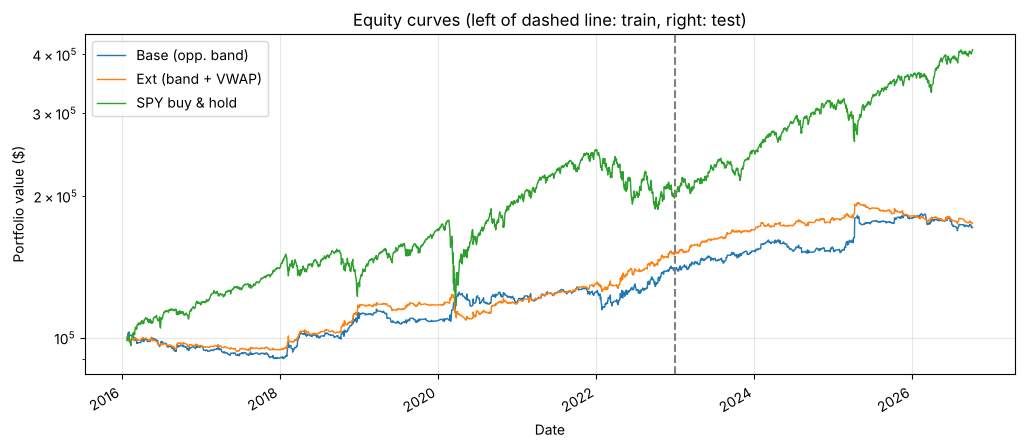

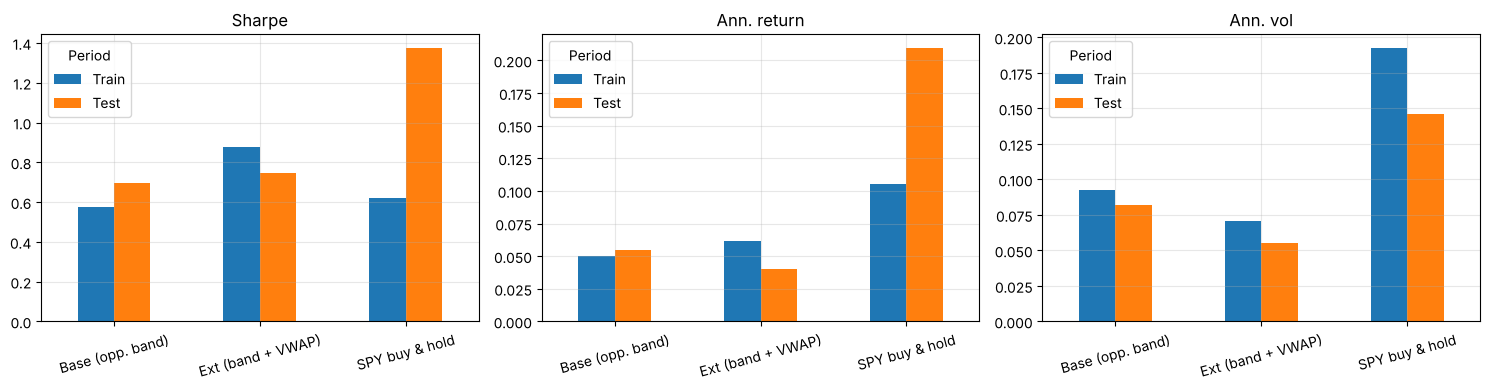

In [11]:
# --- Equity curves (log scale), dashed line = train/test split ---
equity = INITIAL_AUM * (1 + returns).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))
equity.plot(ax=ax, logy=True, linewidth=1)
ax.axvline(pd.Timestamp(SPLIT_DATE), linestyle='--', color='grey')
ax.set_title('Equity curves (left of dashed line: train, right: test)')
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio value ($)')
ax.grid(alpha=0.3)
plt.show()

# --- Sharpe, annualized return, annualized volatility: train vs test ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['Sharpe', 'Ann. return', 'Ann. vol']):
    summary[metric].unstack('Period')[['Train', 'Test']].plot.bar(ax=ax, rot=15)
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## **Part 3. Own strategy: regime-aware intraday momentum**

**Motivation.** Part 2 shows that the performance of the strategy depends strongly on the market environment: it loses in calm years and earns most of its return in volatile ones. The paper reports the same pattern, with the Sharpe ratio increasing with the level of the VIX at the open (Section 4.1, Figure 8), and Rosa (2022) links intraday momentum to volatile regimes using a Markov-switching model. The VIX at the open is known before the first trade at 10:00, so this evidence is already ex ante, and the authors suggest that the strategy "could benefit from dynamically adjusting exposure based on current market volatility". They, however, only report the relation in-sample and do not turn it into a trading rule. Two details are also worth noting: Figure 8 is computed for the volatility-targeted version of the strategy, and the Sharpe ratio there falls again at the highest VIX levels. Our idea is to build such a rule from a regime model and to test it out of sample.

**Model.** We fit a two-regime Markov-switching model (Hamilton, 1989) to daily SPY returns,
$$r_t = \mu_{S_t} + \varepsilon_t, \qquad \varepsilon_t \sim N(0, \sigma^2_{S_t}), \qquad S_t \in \{\text{calm}, \text{volatile}\},$$
where $S_t$ follows a first-order Markov chain. The parameters are estimated on the train period only and are then kept fixed.

**Trading rule.** On day $t$ the extension from Part 2 is traded with an exposure equal to the filtered probability of the volatile regime at the close of day $t-1$,
$$w_t = p_{t-1} = P(S_{t-1} = \text{volatile} \mid r_1, \dots, r_{t-1}).$$
We use filtered rather than smoothed probabilities, because smoothed probabilities are computed from future returns.

**Expected edge and benchmark.** If the edge is concentrated in volatile regimes, the scaled strategy should lose less in calm periods and keep most of the profit in volatile ones, which would raise its Sharpe ratio. To check whether the Markov-switching model adds anything beyond a simple rule, we compare it with a naive filter that trades only when the 14-day realised volatility is above its train median. All versions use the same data split, transaction costs and metrics as in Part 2.

#### **10. Markov-switching regime model (fit on train only)**

In [12]:
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

# Daily close-to-close SPY returns in % (scaling to % helps the optimizer)
spy_daily = 100 * daily_close.pct_change().dropna()
train_daily = spy_daily[spy_daily.index < SPLIT_DATE]

# 2 regimes, each with its own mean and variance (Hamilton, 1989)
ms_model = MarkovRegression(train_daily, k_regimes=2, trend='c', switching_variance=True)
np.random.seed(0)                        # the random starts below are drawn with numpy -> reproducible fit
ms_res = ms_model.fit(search_reps=20)    # several random starts -> avoids bad local optimum
print(ms_res.summary())

# Regime labels are arbitrary: the high-vol regime is the one with larger variance
sigma2 = ms_res.params[['sigma2[0]', 'sigma2[1]']].values
HIGH = int(np.argmax(sigma2))
LOW = 1 - HIGH
print(f"High-vol regime = {HIGH}: daily vol {np.sqrt(sigma2[HIGH]):.2f}% "
      f"vs calm regime {np.sqrt(sigma2[LOW]):.2f}%")

                        Markov Switching Model Results                        
Dep. Variable:                  close   No. Observations:                 1761
Model:               MarkovRegression   Log Likelihood               -2336.379
Date:                Thu, 08 Oct 2026   AIC                           4684.758
Time:                        22:10:46   BIC                           4717.600
Sample:                             0   HQIC                          4696.894
                               - 1761                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1157      0.017      6.800      0.000       0.082       0.149
sigma2         0.2856      0.016     17.765      0.0

#### **11. Filtered regime probability, look-ahead-safe**

In [13]:
# Apply the TRAIN parameters to the full sample (no re-estimation on test data)
ms_full = MarkovRegression(spy_daily, k_regimes=2, trend='c', switching_variance=True)
ms_filt = ms_full.filter(ms_res.params)

# FILTERED probability P(regime_t | returns up to day t).
# Never use smoothed probabilities: they use future data.
p_high_filtered = ms_filt.filtered_marginal_probabilities[HIGH]

# Day t's filtered probability already includes day t's return (known only at the close),
# so for trading on day t we use the probability from day t-1
p_high = p_high_filtered.shift(1).reindex(pos_vwap.index)

p_high.describe()

count    2687.000000
mean        0.351186
std         0.402838
min         0.008360
25%         0.014242
50%         0.076949
75%         0.828748
max         1.000000
Name: 1, dtype: float64

#### **12. Regime probability vs SPY**

The plot is a visual check of the regime model: the probability of the volatile regime should be high in turbulent periods and low in calm ones. Its yearly averages are reported in Section 15 (87% in 2022 and 3% in 2017).

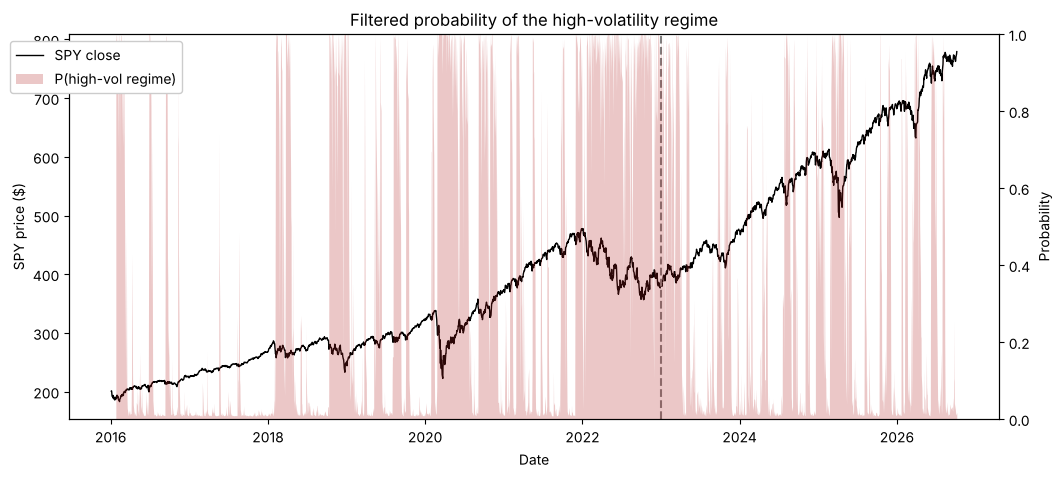

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily_close.index, daily_close, color='black', linewidth=1, label='SPY close')
ax.set_xlabel('Date')
ax.set_ylabel('SPY price ($)')
ax2 = ax.twinx()                                   # second y-axis for the probability
ax2.fill_between(p_high.index, 0, p_high, color='firebrick', alpha=0.25, linewidth=0, label='P(high-vol regime)')
ax2.set_ylabel('Probability')
ax2.set_ylim(0, 1)
ax.axvline(pd.Timestamp(SPLIT_DATE), linestyle='--', color='grey')
ax.set_title('Filtered probability of the high-volatility regime')
fig.legend(loc='upper left', bbox_to_anchor=(0.07, 0.88), framealpha=1)
plt.show()

#### **13. Regime-scaled strategy and naive benchmark**

Both strategies use the positions of the extension from Part 2 and differ only in the daily exposure. The backtest function from Section 6 is reused with its `exposure` argument.

In [15]:
# Naive benchmark: trade only when recent realized vol is above its TRAIN median
rv14 = daily_close.pct_change().rolling(14).std().shift(1).reindex(pos_vwap.index)
rv_threshold = rv14[rv14.index < SPLIT_DATE].median()     # threshold from train only
exposure_naive = (rv14 > rv_threshold).astype(float)

# Our strategy: exposure = probability of the high-vol regime (no threshold to tune)
res_ms    = backtest(pos_vwap, fill_price, close_price, open_price, exposure=p_high)
res_naive = backtest(pos_vwap, fill_price, close_price, open_price, exposure=exposure_naive)

#### **14. Comparison: same split, same costs, same metrics**

Since the scaled strategies invest on average less capital, their returns and volatilities are lower by construction, and the Sharpe ratio is the relevant metric. The column `Avg exposure` reports the average fraction of equity invested. The number of trades of the regime-scaled strategy equals that of the extension, because only the position size changes; its costs fall proportionally with the exposure.

In [16]:
returns3 = pd.DataFrame({
    'Ext (band + VWAP)': res_vwap['ret'],
    'Ext x vol filter':  res_naive['ret'],
    'Ext x MS regime':   res_ms['ret'],
    'SPY buy & hold':    spy_ret,
})
STRATS3 = ['Ext (band + VWAP)', 'Ext x vol filter', 'Ext x MS regime']
returns3[STRATS3] = returns3[STRATS3].fillna(0)     # no trading on the removed days, as in Section 7

trades3 = pd.DataFrame({
    'Ext (band + VWAP)': res_vwap['n_trades'],
    'Ext x vol filter':  res_naive['n_trades'],
    'Ext x MS regime':   res_ms['n_trades'],
}).reindex(returns3.index, fill_value=0)

# Average fraction of capital invested (explains lower return / vol of scaled versions)
avg_exposure = pd.DataFrame({
    'Ext (band + VWAP)': 1.0,
    'Ext x vol filter':  exposure_naive,
    'Ext x MS regime':   p_high,
}, index=pos_vwap.index).reindex(returns3.index)     # NaN on the removed days -> ignored in the mean

periods3 = {'Train': returns3.index < SPLIT_DATE, 'Test': returns3.index >= SPLIT_DATE}

rows = []
for period, mask in periods3.items():
    for strat in returns3.columns:
        m = metrics(returns3.loc[mask, strat])
        m['Trades'] = trades3.loc[returns3.index[mask], strat].sum() if strat in trades3 else np.nan
        m['Avg exposure'] = avg_exposure.loc[mask, strat].mean() if strat in avg_exposure else 1.0
        m['Period'], m['Strategy'] = period, strat
        rows.append(m)

summary3 = pd.DataFrame(rows).set_index(['Period', 'Strategy'])
summary3.round(3)

Ann. return  Ann. vol  Sharpe  Max DD  Hit ratio  \
Period Strategy                                                              
Train  Ext (band + VWAP)        0.061     0.071   0.875  -0.117      0.427   
       Ext x vol filter         0.041     0.064   0.654  -0.120      0.442   
       Ext x MS regime          0.034     0.059   0.604  -0.118      0.427   
       SPY buy & hold           0.106     0.192   0.619  -0.342      0.544   
Test   Ext (band + VWAP)        0.040     0.055   0.746  -0.098      0.460   
       Ext x vol filter         0.006     0.045   0.162  -0.078      0.453   
       Ext x MS regime          0.003     0.034   0.113  -0.052      0.460   
       SPY buy & hold           0.209     0.146   1.374  -0.190      0.564   

                           Skew    Days  Trades  Avg exposure  
Period Strategy                                                
Train  Ext (band + VWAP)  0.783  1748.0  3074.0         1.000  
       Ext x vol filter   0.821  1748.0  1504.0         0.499  
       Ext x MS regime    0.440  1748.0  3074.0         0.378  
       SPY buy & hold    -0.537  1748.0     NaN         1.000  
Test   Ext (band + VWAP)  2.359   943.0  1695.0         1.000  
       Ext x vol filter   3.225   943.0   880.0         0.545  
       Ext x MS regime    6.504   943.0  1695.0         0.302  
       SPY buy & hold     0.455   943.0     NaN         1.000

#### **15. Plots, alpha/beta and yearly returns**

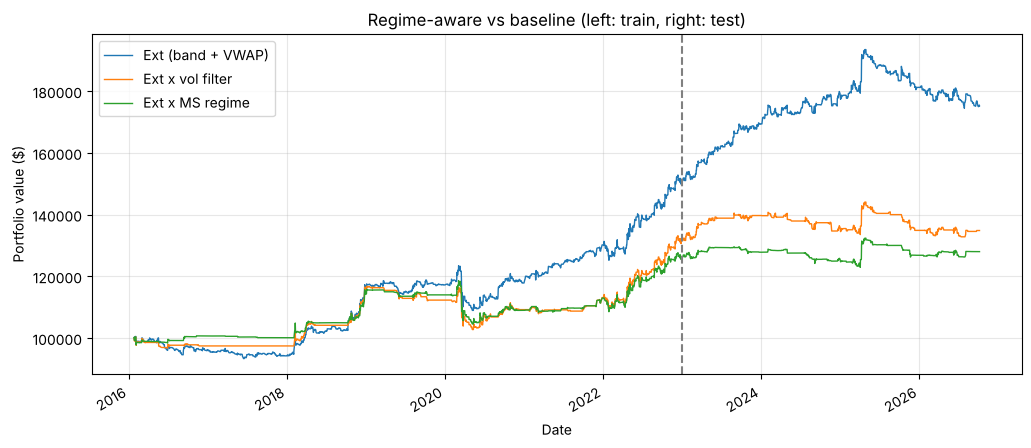

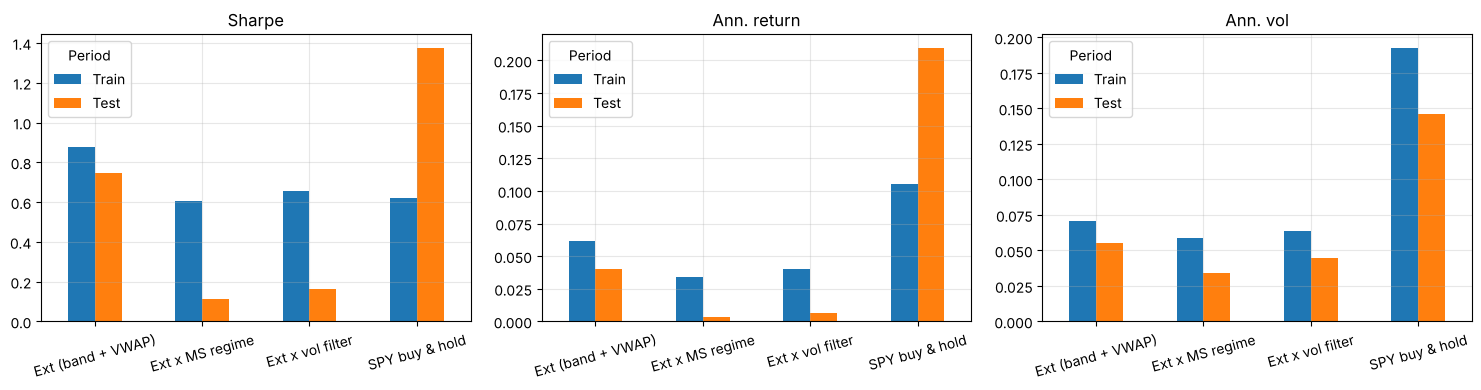

Train | Ext (band + VWAP)  | alpha =  6.43% (t = 2.39) | beta = -0.02
Train | Ext x vol filter   | alpha =  4.32% (t = 1.78) | beta = -0.01
Train | Ext x MS regime    | alpha =  3.64% (t = 1.63) | beta = -0.01
Test  | Ext (band + VWAP)  | alpha =  3.96% (t = 1.39) | beta = 0.01
Test  | Ext x vol filter   | alpha =  0.36% (t = 0.16) | beta = 0.02
Test  | Ext x MS regime    | alpha = -0.11% (t = -0.06) | beta = 0.02


,Ext (band + VWAP),Ext x vol filter,Ext x MS regime,SPY buy & hold,avg P(high-vol)
date,,,,,
2016,-3.7,-2.5,0.7,17.4,22.4
2017,-2.1,0.0,-0.6,19.4,2.6
2018,23.0,18.2,14.1,-6.3,37.3
2019,1.2,-2.5,-0.2,28.7,23.3
2020,0.5,-2.7,-4.4,16.1,61.4
2021,10.5,3.6,3.7,27.0,30.1
2022,16.1,16.4,11.9,-19.5,86.6
2023,12.1,6.0,1.1,24.3,34.9
2024,5.6,-2.9,-1.9,23.3,23.1


In [17]:
# --- Equity curves of the three intraday versions ---
equity3 = INITIAL_AUM * (1 + returns3.drop(columns='SPY buy & hold')).cumprod()
fig, ax = plt.subplots(figsize=(12, 5))
equity3.plot(ax=ax, linewidth=1)
ax.axvline(pd.Timestamp(SPLIT_DATE), linestyle='--', color='grey')
ax.set_title('Regime-aware vs baseline (left: train, right: test)')
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio value ($)')
ax.grid(alpha=0.3)
plt.show()

# --- Sharpe, annualized return, annualized volatility ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['Sharpe', 'Ann. return', 'Ann. vol']):
    summary3[metric].unstack('Period')[['Train', 'Test']].plot.bar(ax=ax, rot=15)
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Alpha / beta vs SPY ---
import statsmodels.api as sm
for period, mask in periods3.items():
    for strat in ['Ext (band + VWAP)', 'Ext x vol filter', 'Ext x MS regime']:
        y = returns3.loc[mask, strat]
        X = sm.add_constant(returns3.loc[mask, 'SPY buy & hold'])
        res = sm.OLS(y, X).fit()
        print(f"{period:5s} | {strat:18s} | alpha = {res.params['const'] * 252:6.2%} "
              f"(t = {res.tvalues['const']:.2f}) | beta = {res.params.iloc[1]:.2f}")

# --- Yearly returns (%) and average regime probability per year ---
yearly3 = returns3.groupby(returns3.index.year).apply(lambda r: (1 + r).prod() - 1)
yearly3['avg P(high-vol)'] = p_high.groupby(p_high.index.year).mean()
(100 * yearly3).round(1)

## **Conclusions and further work**

In Part 2 we replicated the intraday momentum strategy of Zarattini, Aziz and Barbon (2025) on 1-minute SPY data for 2016–2026. The base model reproduces the Sharpe ratio of the paper (0.58 in train and 0.69 in test, against 0.61 in the paper) as well as its daily hit ratio (53.6% for the base model and 42.7% for the extension, against 54% and 43%), and the VWAP trailing stop improves the Sharpe ratio in the train period (0.88) and makes the return distribution positively skewed, as in the paper. The strategy is market-neutral, stays profitable out of sample after realistic costs and earns its best returns in the years when the market falls, which makes it a diversifier rather than a substitute for an index investment.

In Part 3 we tested whether a Markov-switching regime model can tell in advance when to trade the strategy. The model identifies volatility regimes well, but scaling the exposure by the regime probability reduces the Sharpe ratio in both periods, and a naive volatility filter fails in the same way. The yearly returns show why: a large part of the edge is earned in years that the model classifies as mostly calm (2021, 2023 and 2024), and the Noise Area is already volatility-adjusted, so a daily volatility filter removes profitable days together with the losing ones. The key takeaway is that volatility should be used to size positions, not to choose the days to trade, and that trends can only be captured in real time, which the Noise Area already does.

In the future work on this topic, I would like to focus on two directions that follow directly from this conclusion. The first is volatility targeting with a model-based forecast, $w_t = \min\left(4,\ \sigma^{\text{target}} / \hat\sigma_t\right)$, where $\hat\sigma_t$ comes from the Markov-switching model, $\hat\sigma_t^2 = p_t\,\sigma^2_{\text{volatile}} + (1-p_t)\,\sigma^2_{\text{calm}}$ with $p_t$ the predicted regime probability, from a GARCH model, or from a HAR model of intraday realised volatility (Corsi, 2009). The HAR forecast is the most natural choice here, because it measures the intraday risk that the strategy actually bears, while the paper sizes positions by close-to-close volatility, which includes the overnight gaps. The second direction is the exit rule. Since a large share of the return is lost to transaction costs and to stop-outs on choppy days, it would also be interesting to replace the VWAP stop with a CUSUM change-point rule (Page, 1954), which exits only when enough evidence of a reversal has accumulated. Finally, a longer sample including 2008–2015 would make the out-of-sample conclusions more reliable.